# 08 — Full Simulation Smoke Test

End-to-end simulation: 23 agents, 2 days, single policy (Carbon Tax).

1. Load data & build environment (subsample to 23 citizens)
2. Run `run_simulation` with a 2-day config
3. Inspect opinion trajectories and reflections
4. Plot results
5. Save output

**Covers:** Issue 10 (Simulation Loop + Output)

In [15]:
import os, sys, random, logging
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

from cag.io.survey import load
from cag.abm.agent import SurveyedCitizen, PoliticalAgent
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import ClimatePolicyID, SURVEY_QUESTIONS
from cag.abm.sim import run_simulation, save_results, plot_opinion_trajectories

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)
import pandas as pd
import matplotlib.pyplot as plt

print("Imports OK")

Imports OK


## 1. Load Data & Build Environment

Subsample to 23 citizens for a fast smoke test.

In [16]:
N_CITIZENS = 3
random.seed(42)
year = 2026

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

sn = SurveyedNation(
    year=year, place="UK",
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load("../data/yougov_survey_data/YouGovProcessedData_train.csv")
data = data.sample(n=N_CITIZENS, random_state=42)

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=sn,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    sn.agents_active[sc.id] = sc

print(f"Citizens loaded: {len(sn.agents_active)}")

INFO No NaNs found in selected columns.
INFO 651 rows after filtering.


Citizens loaded: 3


## 2. Configure & Run Simulation

2 days, Carbon Tax, standard phase order [P-A, P-B, C].

In [ ]:
config = {
    "n_citizens": 3,
    "days": [
        {"policy": ClimatePolicyID.CARBON_TAX, "phases": ["P-B", "C"]},
        {"policy": ClimatePolicyID.CARBON_TAX, "phases": ["P-B", "C"]},
    ],
    "k_peers_per_day": 3,
    "p_intra": 0.15,
    "p_inter": 0.02,
    "random_seed": 42,
}

print(f"Config: {len(config['days'])} days, {N_CITIZENS} citizens")
print(f"Phases per day: {config['days'][0]['phases']}")
print(f"Policy: {config['days'][0]['policy']}")

Config: 2 days, 3 citizens
Phases per day: ['P-A', 'P-B', 'C']
Policy: ClimatePolicyID(5)


In [5]:
results = run_simulation(config, sn)
print(f"\nSimulation complete.")
print(f"Opinion trajectories: {len(results['opinion_trajectories'])} rows")
print(f"Reflections: {len(results['reflections'])} rows")

INFO Simulation: 3 agents, 2 days
INFO Running baseline survey (day 0), policy=ClimatePolicyID(5)
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO --- Day 1/2 (policy=ClimatePolicyID(5), phases=['P-A', 'P-B', 'C']) ---
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO [P-A] Day 1: delivered message to 1 citizens. Message (first 120 chars): Let’s be clear: the climate crisis and our everyday struggles with rising costs are two sides of the same coin. Fossil f...
INFO [P-A] Sample reflection: This message resonates strongly with my values regarding environmental protection and social equity. The idea of a carbon tax on fossil fuel sales aligns with my commit


Simulation complete.
Opinion trajectories: 9 rows
Reflections: 6 rows


## 3. Opinion Trajectories

In [6]:
df_traj = results["opinion_trajectories"]
print(f"Shape: {df_traj.shape}")
print(f"Columns: {list(df_traj.columns)}")
print(f"Days: {sorted(df_traj['day'].unique())}")
print(f"Policies: {df_traj['policy_id'].unique()}")
print()
df_traj.head(10)

Shape: (9, 4)
Columns: ['agent_id', 'day', 'policy_id', 'numeric']
Days: [np.int64(0), np.int64(1), np.int64(2)]
Policies: <StringArray>
['ClimatePolicyID(5)']
Length: 1, dtype: str



,agent_id,day,policy_id,numeric
0,1463.0,0,ClimatePolicyID(5),3
1,1463.0,1,ClimatePolicyID(5),3
2,1463.0,2,ClimatePolicyID(5),3
3,937.0,0,ClimatePolicyID(5),1
4,937.0,1,ClimatePolicyID(5),1
5,937.0,2,ClimatePolicyID(5),1
6,771.0,0,ClimatePolicyID(5),1
7,771.0,1,ClimatePolicyID(5),-2
8,771.0,2,ClimatePolicyID(5),-2


In [7]:
# Mean opinion by day
mean_by_day = df_traj.groupby("day")["numeric"].mean()
print("Mean opinion by day:")
for day, val in mean_by_day.items():
    print(f"  Day {int(day)}: {val:+.2f}")

Mean opinion by day:
  Day 0: +1.67
  Day 1: +0.67
  Day 2: +0.67


## 4. Reflections

In [8]:
df_ref = results["reflections"]
print(f"Shape: {df_ref.shape}")
print(f"Columns: {list(df_ref.columns)}")
print(f"\nReflections per phase:")
print(df_ref["phase"].value_counts().to_string())
print(f"\nReflections per day:")
print(df_ref["day"].value_counts().sort_index().to_string())

Shape: (6, 5)
Columns: ['agent_id', 'day', 'phase', 'policy_id', 'text']

Reflections per phase:
phase
P-B    4
P-A    2

Reflections per day:
day
1    3
2    3


In [9]:
# Sample reflections from each phase
for phase in ["P-A", "P-B", "C"]:
    subset = df_ref[df_ref["phase"] == phase]
    if subset.empty:
        print(f"--- {phase}: no reflections ---\n")
        continue
    sample = subset.iloc[0]
    print(f"--- {phase} (day {int(sample['day'])}, agent {sample['agent_id']}) ---")
    print(sample["text"][:300])
    print()

--- P-A (day 1, agent 1463.0) ---
This message resonates strongly with my values regarding environmental protection and social equity. The idea of a carbon tax on fossil fuel sales aligns with my commitment to addressing the climate crisis, as it holds polluters accountable for their actions and incentivizes a shift toward renewable

--- P-B (day 1, agent 937.0) ---
This message raises some valid concerns about the potential impact of a carbon tax on everyday families, especially regarding rising energy costs and the burden it could place on working-class individuals. I do share a respect for nature and recognize the importance of addressing climate change, but

--- C: no reflections ---



## 5. Plot Opinion Trajectories

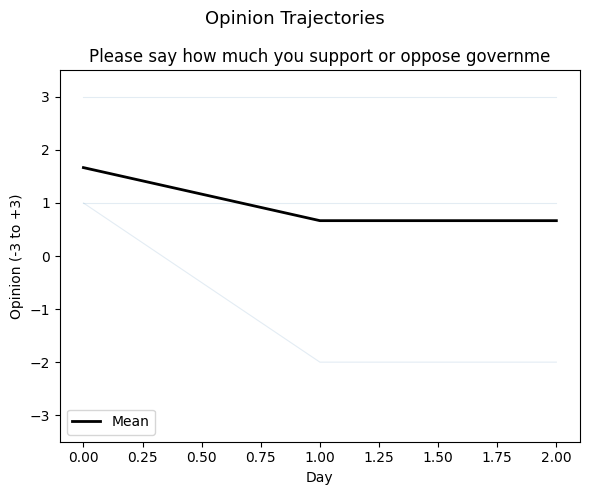

In [10]:
fig = plot_opinion_trajectories(results)
plt.show()

## 6. Save Results

In [12]:
out_path = save_results(results, output_dir="../data/output/experiments")
print(f"Saved to: {out_path}")

# Verify files exist
for fname in ["opinion_trajectories.csv", "reflections.csv", "config.json"]:
    path = out_path / fname
    print(f"  {fname}: {path.stat().st_size:,} bytes")

INFO Results saved to ../data/output/experiments/20260416_144332


Saved to: ../data/output/experiments/20260416_144332
  opinion_trajectories.csv: 297 bytes
  reflections.csv: 7,166 bytes
  config.json: 546 bytes


## 7. Sanity Checks

In [13]:
n_days = len(config["days"])
n_agents = len(sn.agents_active)

checks = []

# Trajectory has baseline + n_days rows per agent
expected_rows = n_agents * (n_days + 1)  # day 0 baseline + 2 days
actual_rows = len(df_traj)
checks.append(("Trajectory row count", actual_rows == expected_rows,
                f"expected {expected_rows}, got {actual_rows}"))

# All agents present in trajectories
n_unique_agents = df_traj["agent_id"].nunique()
checks.append(("All agents in trajectories", n_unique_agents == n_agents,
                f"expected {n_agents}, got {n_unique_agents}"))

# Opinions in valid range
in_range = df_traj["numeric"].between(-3, 3).all()
checks.append(("Opinions in [-3, +3]", in_range, ""))

# Days 0, 1, 2 present
expected_days = set(range(n_days + 1))
actual_days = set(df_traj["day"].unique())
checks.append(("Correct days present", actual_days == expected_days,
                f"expected {expected_days}, got {actual_days}"))

# Reflections exist
checks.append(("Reflections non-empty", len(df_ref) > 0,
                f"got {len(df_ref)} reflections"))

# Config JSON is valid
import json
with open(out_path / "config.json") as f:
    saved_config = json.load(f)
checks.append(("Config JSON valid", isinstance(saved_config, dict), ""))

for name, passed, detail in checks:
    status = "PASS" if passed else "FAIL"
    suffix = f" ({detail})" if detail else ""
    print(f"[{status}] {name}{suffix}")

n_passed = sum(1 for _, p, _ in checks if p)
print(f"\n{n_passed}/{len(checks)} checks passed")

[PASS] Trajectory row count (expected 9, got 9)
[PASS] All agents in trajectories (expected 3, got 3)
[PASS] Opinions in [-3, +3]
[PASS] Correct days present (expected {0, 1, 2}, got {np.int64(0), np.int64(1), np.int64(2)})
[PASS] Reflections non-empty (got 6 reflections)
[PASS] Config JSON valid

6/6 checks passed


## 8. LLM Call Estimate

Back-of-envelope cost for this smoke test.

In [14]:
n_a = len(sn.political_agent_a.connected_citizens)
n_b = len(sn.political_agent_b.connected_citizens)
n_days = len(config["days"])

# Per day: generate_message(2) + broadcast_reflections(n_a + n_b)
#        + peer_messages(n) + peer_reflections(n) + survey(n)
#        + memory_compression(n)
per_day = 2 + n_a + n_b + n_agents + n_agents + n_agents + n_agents
baseline = n_agents  # day 0 survey
total = baseline + per_day * n_days

print(f"Agents: {n_agents} (A-connected: {n_a}, B-connected: {n_b})")
print(f"Baseline (day 0): {baseline} calls")
print(f"Per day: ~{per_day} calls")
print(f"Total for {n_days} days: ~{total} LLM calls")

Agents: 3 (A-connected: 1, B-connected: 2)
Baseline (day 0): 3 calls
Per day: ~17 calls
Total for 2 days: ~37 LLM calls
